<a href="https://colab.research.google.com/github/mantle-bearer/nigeria-dl-datasets/blob/main/notebook6f6ebc51ab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🪪 Nigerian Driver's Licence — Synthetic Dataset Generator
**YardSense OCR Pipeline | Pre-training Data Preparation**

This notebook generates a synthetic dataset of Nigerian FRSC Driver's Licence cards for fine-tuning PaddleOCR PP-OCRv4-mobile.  
All data is algorithmically generated — no real PII is used.

**What this produces:**
- Photorealistic card images (clean + augmented variants)
- Ground truth CSV with all field values per image
- PaddleOCR-ready JSONL label file with bounding boxes
- Field-level crop images for targeted recognition fine-tuning
- Dataset split into `train/val/test` folders

**Pipeline stages:**
```
Generate record → Render card → Apply augmentation → Save image + labels
```

In [1]:
# ─────────────────────────────────────────────────────────
# CELL 1 — Install system fonts and dependencies
# ─────────────────────────────────────────────────────────
!apt-get install -y fonts-liberation fonts-freefont-ttf > /dev/null 2>&1
!pip install pillow numpy pandas tqdm -q
print('✓ Dependencies ready')

✓ Dependencies ready


In [2]:
# ─────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────
import os, json, random, string, shutil, io
from datetime import date, timedelta
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFilter

print('✓ Imports OK')

✓ Imports OK


In [3]:
# ─────────────────────────────────────────────────────────
# CELL 3 — Mount Google Drive
# ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('✓ Drive mounted')

Mounted at /content/drive
✓ Drive mounted


In [4]:
# ─────────────────────────────────────────────────────────
# CELL 4 — Configuration
# Adjust N_SAMPLES and OUTPUT_ROOT as needed.
# ─────────────────────────────────────────────────────────

OUTPUT_ROOT = '/content/drive/MyDrive/NigeriaDL_Dataset'

CFG = {
    'n_samples'    : 5000,     # total images to generate
    'card_w'       : 600,      # card pixel width
    'card_h'       : 380,      # card pixel height
    'aug_prob'     : 0.90,     # probability of applying augmentation per image
    'seed'         : 42,
    'splits'       : {'train': 0.80, 'val': 0.10, 'test': 0.10},
    'jpeg_quality' : (72, 96), # range for JPEG compression simulation
    'clean_copies' : True,     # also save a clean (no augmentation) copy for reference
}

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])

# ── Build directory tree ──────────────────────────────────
DIRS = {}
for split in CFG['splits']:
    p = Path(OUTPUT_ROOT) / split / 'images'
    p.mkdir(parents=True, exist_ok=True)
    DIRS[split] = p

CROP_DIR   = Path(OUTPUT_ROOT) / 'field_crops'
LABEL_DIR  = Path(OUTPUT_ROOT) / 'labels'
CLEAN_DIR  = Path(OUTPUT_ROOT) / 'clean_reference'
for d in [CROP_DIR, LABEL_DIR, CLEAN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Create per-field crop subdirectories
CROP_FIELDS = ['license_no','name','dob','exp','iss','phone','first_iss','sex','height']
for f in CROP_FIELDS:
    (CROP_DIR / f).mkdir(exist_ok=True)

print('✓ Directory structure created at:', OUTPUT_ROOT)
for s, p in DIRS.items():
    print(f'   {s:6s} → {p}')

✓ Directory structure created at: /content/drive/MyDrive/NigeriaDL_Dataset
   train  → /content/drive/MyDrive/NigeriaDL_Dataset/train/images
   val    → /content/drive/MyDrive/NigeriaDL_Dataset/val/images
   test   → /content/drive/MyDrive/NigeriaDL_Dataset/test/images


In [5]:
# ─────────────────────────────────────────────────────────
# CELL 5 — Nigerian Data Corpus
# Realistic names, states, addresses, and field values
# ─────────────────────────────────────────────────────────

FIRST_NAMES = [
    # Yoruba
    'ADEBAYO','ADEWALE','ADEYEMI','AFOLABI','BABATUNDE','BIODUN',
    'FUNMILAYO','OLUWASEUN','OLUWAFEMI','OLUWAKEMI','SEGUN','TAIWO',
    'KEHINDE','TUNDE','YINKA','TOYIN','FOLAKE','BUNMI','WUNMI','GBEMISOLA',
    'OLUMIDE','OLUWASEYI','ADEDAYO','ADEWUNMI','OLAWALE',
    # Igbo
    'CHUKWUEMEKA','EMEKA','CHINEDU','OBINNA','IFEANYI','UCHE','NNAMDI',
    'KELECHI','AMARACHI','EZINNE','CHIOMA','NGOZI','ADAEZE','CHIKAMSO',
    'ONYEKA','CHUKWUDI','IKECHUKWU','OBIORA','NNEKA','ADAORA','CHINONSO',
    'CHIDINMA','IFEOMA','OGECHUKWU','CHIAMAKA',
    # Hausa / Northern
    'IBRAHIM','MUSA','AHMED','ABDULLAHI','SULEIMAN','ABUBAKAR',
    'YAKUBU','GARBA','AMINU','BELLO','FATIMA','AISHA','HAUWA',
    'ZAINAB','MARYAM','RABIU','DANLADI','HARUNA','TANKO','ALIYU',
    'HUSSAINI','NUHU','IDRIS','KABIRU','SADIYA',
    # Edo / Delta / South-South
    'OSARO','EHI','OSAGIE','EHIGIE','BLESSING','GODWIN','SUNDAY',
    # General Christian
    'PETER','PAUL','JOHN','JAMES','SAMUEL','DAVID','GRACE','MERCY',
    'JOY','FAITH','VICTOR','MONDAY','SUCCESS','BRIGHT','FESTUS',
]

LAST_NAMES = [
    # Yoruba
    'ADEYEMI','ADELEKE','AFOLABI','AKINTOLA','COKER','FASHOLA',
    'OGUNDIMU','ALABI','ADEOLA','ADEKUNLE','ADEWUSI','MAKINDE',
    'ABIODUN','OGUNYEMI','AYODELE','OMOTOSHO','ADEGBOYEGA',
    # Igbo
    'OKONKWO','OKAFOR','EZE','NWACHUKWU','IGWE','OBIORA','ONUOHA',
    'OKEKE','NWOSU','ONYEKA','UGWU','NWANKWO','OGBONNA','CHUKWU',
    'NNADI','OBI','ANYANWU','IHEJIRIKA','OZOEMENA','ESINAME',
    # Hausa
    'BELLO','ALIYU','USMAN','DANJUMA','HARUNA','ABUBAKAR','YAKUBU',
    'GARBA','LAWAN','SANI','TANKO','MUSA','IBRAHIM','AHMAD',
    'HUSSAINI','DANLADI','BALA','NUHU','IDRIS','RABIU',
    # Edo / South-South
    'OBASEKI','OKORO','EKANEM','EKPO','AMAECHI','DICKSON','EWETA',
    'ORJI','OTIVE','OVIAWE','IMASUEN','OMOREGIE',
    # Rivers / Ijaw
    'WIKE','DIRI','SYLVA','AGBI','BORO','TORUGBENE','EBIKABARA',
]

MIDDLE_NAMES = [
    'SOLA','TUNDE','FEMI','WALE','SEUN','TOBI','CHUKWU','NKEM',
    'NNEKA','ADAORA','CHIDERA','HUSSAINI','SANI','BALA','DANLADI',
    'BRIGHT','DAVID','MICHAEL','JOHN','JAMES','EMEKA','UCHE',
    'KELECHI','OBIORA','IFEANYI','FOLAKE','YINKA','BIODUN','MUSA',
]

# State name → licence prefix
STATES = {
    'LAGOS STATE'        : 'LSD',
    'FCT ABUJA'          : 'FCT',
    'RIVERS STATE'       : 'RSV',
    'KANO STATE'         : 'KAN',
    'OGUN STATE'         : 'OGN',
    'OYO STATE'          : 'OYO',
    'ANAMBRA STATE'      : 'ANM',
    'IMO STATE'          : 'IMO',
    'ENUGU STATE'        : 'ENU',
    'DELTA STATE'        : 'DEL',
    'EDO STATE'          : 'EDO',
    'CROSS RIVER STATE'  : 'CRV',
    'AKWA IBOM STATE'    : 'AKW',
    'KADUNA STATE'       : 'KAD',
    'KATSINA STATE'      : 'KAT',
    'SOKOTO STATE'       : 'SKT',
    'NIGER STATE'        : 'NGR',
    'BORNO STATE'        : 'BRN',
    'PLATEAU STATE'      : 'PLA',
    'BENUE STATE'        : 'BEN',
    'KWARA STATE'        : 'KWR',
    'OSUN STATE'         : 'OSN',
    'EKITI STATE'        : 'EKT',
    'ONDO STATE'         : 'OND',
    'ABIA STATE'         : 'ABI',
    'EBONYI STATE'       : 'EBN',
    'BAUCHI STATE'       : 'BAU',
    'ADAMAWA STATE'      : 'ADM',
    'GOMBE STATE'        : 'GMB',
    'TARABA STATE'       : 'TAR',
    'KEBBI STATE'        : 'KEB',
    'JIGAWA STATE'       : 'JIG',
    'ZAMFARA STATE'      : 'ZAM',
    'BAYELSA STATE'      : 'BYL',
    'NASARAWA STATE'     : 'NAS',
    'YOBE STATE'         : 'YOB',
}

STATE_CITIES = {
    'LAGOS STATE': 'LAGOS',       'FCT ABUJA': 'ABUJA',
    'RIVERS STATE': 'PH',         'KANO STATE': 'KANO',
    'OGUN STATE': 'ABEOKUTA',     'OYO STATE': 'IBADAN',
    'ANAMBRA STATE': 'AWKA',      'IMO STATE': 'OWERRI',
    'ENUGU STATE': 'ENUGU',       'DELTA STATE': 'ASABA',
    'EDO STATE': 'BENIN',         'CROSS RIVER STATE': 'CALABAR',
    'AKWA IBOM STATE': 'UYO',     'KADUNA STATE': 'KADUNA',
    'KATSINA STATE': 'KATSINA',   'PLATEAU STATE': 'JOS',
    'BENUE STATE': 'MAKURDI',     'KWARA STATE': 'ILORIN',
    'OSUN STATE': 'OSOGBO',       'EKITI STATE': 'ADO-EKITI',
    'ONDO STATE': 'AKURE',        'ABIA STATE': 'UMUAHIA',
}

STREET_TYPES = ['ROAD','STREET','AVENUE','CLOSE','CRESCENT','WAY','LANE','DRIVE']
STREET_NAMES = [
    'ALLEN','BROAD','MARINA','INDEPENDENCE','FREEDOM','FEDERAL',
    'UNITY','PEACE','OLD','NEW','CHURCH','MARKET','HOSPITAL',
    'MISSION','CHIEF','VICTORIA','QUEEN','KING','COLLEGE',
]
AREAS = [
    'IKEJA','SURULERE','LEKKI','APAPA','OJODU','IKORODU','AGEGE',
    'MUSHIN','OSHODI','ISOLO','WUSE','GARKI','MAITAMA','ASOKORO',
    'TRANS-AMADI','GRA','RUMUOLA','ELEKAHIA','KANO MUNICIPAL',
    'SABON GARI','FAGGE','DALA','GWALE','TARAUNI','NASSARAWA',
    'UNIZIK JUNCTION','AWKA SOUTH','NNEWI NORTH','ONITSHA',
    'OWERRI MUNICIPAL','ORLU','OKIGWE','IJEBU-ODE','SAGAMU',
]

print(f'✓ Corpus loaded: {len(FIRST_NAMES)} first names, {len(LAST_NAMES)} last names, {len(STATES)} states')

✓ Corpus loaded: 97 first names, 76 last names, 36 states


In [6]:
# ─────────────────────────────────────────────────────────
# CELL 6 — Field Value Generators
# All functions return strings in exact FRSC card format
# ─────────────────────────────────────────────────────────

def gen_license_number(prefix: str) -> str:
    """Pattern from real cards: PREFIX + 5 digits + 2 uppercase letters + 1 digit.
       Examples: LSD01953AA6, AKW06398AA2, FCT12345BC7
    """
    digits  = ''.join(random.choices(string.digits, k=5))
    letters = ''.join(random.choices(string.ascii_uppercase, k=2))
    suffix  = random.choice(string.digits)
    return f'{prefix}{digits}{letters}{suffix}'


def gen_date(start_year: int, end_year: int):
    """Return (str DD-MM-YYYY, date object)."""
    start = date(start_year, 1, 1)
    end   = date(end_year, 12, 31)
    rand  = start + timedelta(days=random.randint(0, (end - start).days))
    return rand.strftime('%d-%m-%Y'), rand


def gen_name() -> str:
    """LASTNAME FIRSTNAME [MIDDLENAME] — all caps, FRSC format."""
    last  = random.choice(LAST_NAMES)
    first = random.choice(FIRST_NAMES)
    if random.random() < 0.72:            # 72% have a middle name
        mid = random.choice(MIDDLE_NAMES)
        return f'{last} {first} {mid}'
    return f'{last} {first}'


def gen_address(state: str) -> tuple:
    """Return (addr_line1, addr_line2) matching FRSC address block style."""
    num    = random.randint(1, 250)
    street = f'{num}, {random.choice(STREET_NAMES)} {random.choice(STREET_TYPES)}'
    area   = random.choice(AREAS)
    city   = STATE_CITIES.get(state, state.replace(' STATE', ''))
    return street[:38], f'{area}, {city}'  # truncate to fit card


def gen_phone() -> str:
    """Valid Nigerian mobile number (11 digits)."""
    prefixes = ['0803','0806','0813','0816','0703','0706',
                '0810','0811','0902','0903','0907','0905',
                '0805','0807','0815','0908','0915','0901']
    return random.choice(prefixes) + ''.join(random.choices(string.digits, k=7))


def gen_height() -> str:
    """Height in FRSC format: e.g. 1.79M"""
    h = round(random.uniform(1.50, 1.96), 2)
    return f'{h:.2f}M'


def gen_record() -> dict:
    """Generate one complete, internally consistent DL record."""
    state  = random.choice(list(STATES.keys()))
    prefix = STATES[state]

    dob_str, dob = gen_date(1955, 2000)

    # Issue must be after 18th birthday; cap at 2023
    min_iss_yr = min(max(dob.year + 18, 2005), 2023)
    iss_str, iss = gen_date(min_iss_yr, 2023)

    # Expiry = issue date + exactly 5 years
    try:
        exp = iss.replace(year=iss.year + 5)
    except ValueError:                      # Feb 29 edge case
        exp = iss.replace(year=iss.year + 5, day=28)
    exp_str = exp.strftime('%d-%m-%Y')

    # First issue: 0–730 days before current issue
    first_iss = iss - timedelta(days=random.randint(0, 730))
    first_iss_str = first_iss.strftime('%d-%m-%Y')
    first_iss_st  = prefix[:3]             # e.g. 'LSD', 'FCT', 'RSV'

    addr1, addr2 = gen_address(state)

    return {
        'license_no'   : gen_license_number(prefix),
        'state'        : state,
        'state_prefix' : prefix,
        'name'         : gen_name(),
        'dob'          : dob_str,
        'iss'          : iss_str,
        'exp'          : exp_str,
        'first_iss'    : first_iss_str,
        'first_iss_st' : first_iss_st,
        'addr1'        : addr1,
        'addr2'        : addr2,
        'sex'          : random.choice(['M', 'F']),
        'height'       : gen_height(),
        'phone'        : gen_phone(),
        'vehicle_class': random.choice(['A', 'B']),
        'fimarks'      : random.choice(['N', 'YES', 'NONE', 'NIL']),
        'gl'           : random.choice(['N', 'Y', 'NIL']),
        'rep_b'        : f'EN{random.randint(1, 3)}',
    }

# Sanity check
sample = gen_record()
print('✓ Sample record:')
for k, v in sample.items():
    print(f'   {k:15s}: {v}')

✓ Sample record:
   license_no     : IMO68040FN0
   state          : IMO STATE
   state_prefix   : IMO
   name           : SYLVA CHUKWUEMEKA KELECHI
   dob            : 30-03-1957
   iss            : 19-08-2021
   exp            : 19-08-2026
   first_iss      : 11-11-2020
   first_iss_st   : IMO
   addr1          : 63, PEACE AVENUE
   addr2          : AGEGE, OWERRI
   sex            : F
   height         : 1.60M
   phone          : 09028086319
   vehicle_class  : B
   fimarks        : N
   gl             : N
   rep_b          : EN2


In [7]:
# ─────────────────────────────────────────────────────────
# CELL 7 — Font Loader & Card Constants
# ─────────────────────────────────────────────────────────

def load_fonts() -> dict:
    bold_paths = [
        '/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
        '/usr/share/fonts/truetype/freefont/FreeSansBold.ttf',
    ]
    reg_paths = [
        '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
        '/usr/share/fonts/truetype/freefont/FreeSans.ttf',
    ]
    def pick(paths, size):
        for p in paths:
            if os.path.exists(p):
                return ImageFont.truetype(p, size)
        return ImageFont.load_default()

    return {
        'hdr_lg'  : pick(bold_paths, 11),   # header top line
        'hdr_sm'  : pick(bold_paths,  9),   # header sub-line
        'label'   : pick(reg_paths,   9),   # field labels
        'value'   : pick(bold_paths, 11),   # field values
        'value_sm': pick(bold_paths,  9),   # small field values
        'name'    : pick(bold_paths, 12),   # name line
        'licno'   : pick(bold_paths, 10),   # license number
    }

FONTS = load_fonts()

# ── Card colour palette (matched to real FRSC cards) ─────
C_HDR_BG    = ( 0, 102,  51)   # FRSC dark green
C_HDR_TXT   = (255, 255, 255)
C_SUBHDR    = ( 0, 140,  70)   # lighter green band
C_BODY      = (252, 248, 240)  # warm cream body
C_LABEL     = (110, 110, 110)  # muted label grey
C_VALUE     = ( 10,  10,  10)  # near-black values
C_BORDER    = (  0,  80,  40)
C_PHOTO_BG  = (185, 185, 185)
C_FLAG_GRN  = (  0, 134,  63)
C_FLAG_WHT  = (255, 255, 255)

W = CFG['card_w']
H = CFG['card_h']

# ── Bounding boxes for each field value ──────────────────
# Format: (x, y, width, height) — pixel coords in the final rendered card
# These are used for: (a) ground truth labels, (b) field crop extraction
FIELD_BOXES = {
    'license_no'   : (195, 66,  195, 16),
    'dob'          : (195, 86,  135, 16),
    'iss'          : (410, 86,   80, 16),
    'exp'          : (513, 86,   80, 16),
    'name'         : (155, 106, 430, 16),
    'addr1'        : (155, 122, 430, 14),
    'addr2'        : (155, 137, 430, 14),
    'sex'          : (182, 155,  22, 14),
    'height'       : (240, 155,  65, 14),
    'first_iss_st' : (455, 155,  50, 14),
    'fimarks'      : (215, 171,  55, 14),
    'gl'           : (300, 171,  28, 14),
    'rep_b'        : (370, 171,  45, 14),
    'phone'        : (225, 188, 125, 14),
    'vehicle_class': (182, 207,  22, 14),
    'first_iss'    : (300, 225, 105, 14),
}

print('✓ Fonts and layout constants ready')
print(f'   Card size: {W}×{H}px | {len(FIELD_BOXES)} tracked field boxes')

✓ Fonts and layout constants ready
   Card size: 600×380px | 16 tracked field boxes


✓ Template renderer OK — showing sample card:


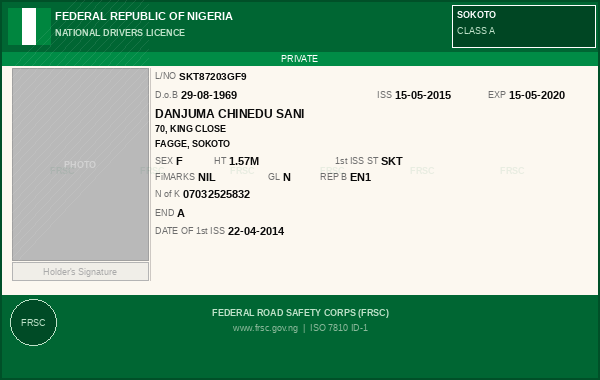

In [9]:
import os, json, random, string, shutil, io
from datetime import date, timedelta
from pathlib import Path
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFilter

# ─────────────────────────────────────────────────────────
# CELL 8 — Card Template Renderer
# Draws a complete FRSC DL card for a given record dict
# ─────────────────────────────────────────────────────────

def draw_card(record: dict) -> Image.Image:
    """Render one Nigerian DL card from a record dict.
    Returns a PIL Image (RGB, CFG card_w × card_h).
    """
    img  = Image.new('RGB', (W, H), C_BODY)
    draw = ImageDraw.Draw(img)

    # ── Header bar (dark green) ──────────────────────────
    draw.rectangle([(0, 0), (W, 52)], fill=C_HDR_BG)

    # Nigerian flag — 3 vertical strips, left of header
    fx = 8
    draw.rectangle([(fx,    8), (fx+14, 44)], fill=C_FLAG_GRN)
    draw.rectangle([(fx+14, 8), (fx+28, 44)], fill=C_FLAG_WHT)
    draw.rectangle([(fx+28, 8), (fx+42, 44)], fill=C_FLAG_GRN)

    # Header text
    draw.text((55, 10), 'FEDERAL REPUBLIC OF NIGERIA',
              fill=C_HDR_TXT, font=FONTS['hdr_lg'])
    draw.text((55, 27), 'NATIONAL DRIVERS LICENCE',
              fill=(190, 225, 200), font=FONTS['hdr_sm'])

    # State badge — top right
    state_label = record['state'].replace(' STATE', '').replace(' ABUJA', '')
    bx = W - 148
    draw.rectangle([(bx, 5), (W - 5, 47)],
                   fill=(0, 70, 35), outline=C_FLAG_WHT, width=1)
    draw.text((bx + 5, 9),  state_label,
              fill=C_HDR_TXT, font=FONTS['hdr_sm'])
    draw.text((bx + 5, 25), f"CLASS {record['vehicle_class']}",
              fill=(190, 225, 200), font=FONTS['label'])

    # ── Sub-header band (lighter green) ─────────────────
    draw.rectangle([(0, 52), (W, 65)], fill=C_SUBHDR)
    draw.text((W // 2, 58), 'PRIVATE',
              fill=C_HDR_TXT, font=FONTS['label'], anchor='mm')

    # ── Photo area ───────────────────────────────────────
    draw.rectangle([(12, 68), (148, 260)],
                   fill=C_PHOTO_BG, outline=(160, 160, 160), width=1)
    draw.text((80, 164), 'PHOTO', fill=(210, 210, 210),
              font=FONTS['hdr_sm'], anchor='mm')

    # Signature strip under photo
    draw.rectangle([(12, 262), (148, 280)],
                   fill=(240, 238, 232), outline=(180, 180, 180), width=1)
    draw.text((80, 271), "Holder's Signature",
              fill=(170, 170, 170), font=FONTS['label'], anchor='mm')

    # Vertical separator
    draw.line([(150, 68), (150, 280)], fill=(205, 200, 195), width=1)

    # ── Field labels ─────────────────────────────────────
    field_labels = [
        ('L/NO',            155,  70),
        ('D.o.B',           155,  89),
        ('ISS',             377,  89),
        ('EXP',             488,  89),
        ('SEX',             155, 155),
        ('HT',              214, 155),
        ('1st ISS ST',      335, 155),
        ('FiMARKS',         155, 171),
        ('GL',              268, 171),
        ('REP B',           320, 171),
        ('N of K',          155, 188),
        ('END',             155, 207),
        ('DATE OF 1st ISS', 155, 225),
    ]
    for lbl, lx, ly in field_labels:
        draw.text((lx, ly), lbl, fill=C_LABEL, font=FONTS['label'])

    # ── Field values ─────────────────────────────────────
    def lv(label_text, lx, font=FONTS['label']): # Removed 'ly' parameter
        """Return x position just after a label."""
        return lx + int(draw.textlength(label_text + ' ', font=font)) + 1

    # License number
    draw.text((lv('L/NO', 155), 70),
              record['license_no'], fill=C_VALUE, font=FONTS['licno'])

    # Dates row
    draw.text((lv('D.o.B', 155), 89),
              record['dob'], fill=C_VALUE, font=FONTS['value'])
    draw.text((lv('ISS', 377), 89),
              record['iss'], fill=C_VALUE, font=FONTS['value'])
    draw.text((lv('EXP', 488), 89),
              record['exp'], fill=C_VALUE, font=FONTS['value'])

    # Name (larger, bolder)
    draw.text((155, 107), record['name'][:42],
              fill=C_VALUE, font=FONTS['name'])

    # Address
    draw.text((155, 123), record['addr1'],
              fill=C_VALUE, font=FONTS['value_sm'])
    draw.text((155, 138), record['addr2'],
              fill=C_VALUE, font=FONTS['value_sm'])

    # SEX / HT / 1st ISS ST row
    draw.text((lv('SEX', 155), 155),
              record['sex'], fill=C_VALUE, font=FONTS['value'])
    draw.text((lv('HT', 214), 155),
              record['height'], fill=C_VALUE, font=FONTS['value'])
    draw.text((lv('1st ISS ST', 335), 155),
              record['first_iss_st'], fill=C_VALUE, font=FONTS['value'])

    # FiMARKS / GL / REP B row
    draw.text((lv('FiMARKS', 155), 171),
              record['fimarks'], fill=C_VALUE, font=FONTS['value'])
    draw.text((lv('GL', 268), 171),
              record['gl'], fill=C_VALUE, font=FONTS['value'])
    draw.text((lv('REP B', 320), 171),
              record['rep_b'], fill=C_VALUE, font=FONTS['value'])

    # N of K
    draw.text((lv('N of K', 155), 188),
              record['phone'], fill=C_VALUE, font=FONTS['value'])

    # END class
    draw.text((lv('END', 155), 207),
              record['vehicle_class'], fill=C_VALUE, font=FONTS['value'])

    # DATE OF 1st ISS
    draw.text((lv('DATE OF 1st ISS', 155), 225),
              record['first_iss'], fill=C_VALUE, font=FONTS['value'])

    # ── Footer bar ───────────────────────────────────────
    draw.rectangle([(0, 295), (W, H)], fill=C_HDR_BG)
    draw.text((W // 2, 312), 'FEDERAL ROAD SAFETY CORPS (FRSC)',
              fill=(190, 225, 200), font=FONTS['hdr_sm'], anchor='mm')
    draw.text((W // 2, 327), 'www.frsc.gov.ng  |  ISO 7810 ID-1',
              fill=(140, 185, 155), font=FONTS['label'], anchor='mm')

    # FRSC circle emblem (bottom left)
    draw.ellipse([(10, 299), (56, 345)],
                 fill=(0, 75, 38), outline=(190, 225, 200), width=1)
    draw.text((33, 322), 'FRSC', fill=(190, 225, 200),
              font=FONTS['label'], anchor='mm')

    # ── Card border ──────────────────────────────────────
    draw.rectangle([(0, 0), (W - 1, H - 1)],
                   outline=C_BORDER, width=2)

    # ── Subtle holographic diagonal sheen on photo area ──
    # Single RGBA composite — not a loop — for performance
    holo = Image.new('RGBA', (W, H), (0, 0, 0, 0))
    hd   = ImageDraw.Draw(holo)
    for i in range(0, 200, 9):
        hd.line([(12, 68 + i), (148, 68 + i - 145)],
                fill=(255, 255, 255, 22), width=1)
    img = Image.alpha_composite(img.convert('RGBA'), holo).convert('RGB')

    # ── Faint FRSC watermark across body ─────────────────
    wm = Image.new('RGBA', (W, H), (0, 0, 0, 0))
    wd = ImageDraw.Draw(wm)
    for xi in range(50, W - 50, 90):
        wd.text((xi, 165), 'FRSC',
                fill=(0, 102, 51, 20), font=FONTS['hdr_sm'])
    img = Image.alpha_composite(img.convert('RGBA'), wm).convert('RGB')

    return img


# Quick preview — render one card and show it
preview_record = gen_record()
preview_img    = draw_card(preview_record)
print('✓ Template renderer OK — showing sample card:')
preview_img

✓ Augmentation pipeline ready — comparison strip below:


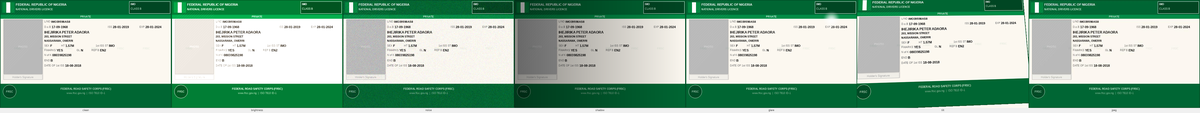

In [10]:
# ─────────────────────────────────────────────────────────
# CELL 9 — Augmentation Pipeline
# 6 degradation types matching real webcam gate conditions
# Each function is independent and stackable
# ─────────────────────────────────────────────────────────

def aug_brightness_contrast(img: Image.Image) -> Image.Image:
    """Simulates outdoor lighting variation: direct sun vs overcast vs night gate.
    Applies random per-channel multiplicative + additive shift.
    """
    arr = np.array(img, dtype=np.float32)
    # Brightness: multiplicative global scale
    brightness = random.uniform(0.55, 1.45)
    arr = arr * brightness
    # Contrast: shift mean toward grey
    contrast = random.uniform(0.80, 1.25)
    arr = (arr - 127.5) * contrast + 127.5
    # Colour temperature shift: slightly warm or cool
    temp = random.uniform(-12, 12)
    arr[:, :, 0] = np.clip(arr[:, :, 0] + temp, 0, 255)    # R
    arr[:, :, 2] = np.clip(arr[:, :, 2] - temp, 0, 255)    # B
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def aug_gaussian_noise(img: Image.Image) -> Image.Image:
    """Webcam sensor noise. Sigma sampled from realistic range."""
    arr   = np.array(img, dtype=np.float32)
    sigma = random.uniform(3.0, 18.0)
    noise = np.random.normal(0, sigma, arr.shape).astype(np.float32)
    arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def aug_shadow_gradient(img: Image.Image) -> Image.Image:
    """One-sided shadow: simulates outdoor sun casting shadow across half the card.
    The shadow ramp is a smooth linear gradient — not a hard edge.
    """
    arr    = np.array(img, dtype=np.float32)
    w      = arr.shape[1]
    direction = random.choice(['left', 'right', 'top', 'bottom'])
    shadow    = random.uniform(0.35, 0.70)     # darkest multiplier

    ramp = np.linspace(shadow, 1.0, w if direction in ('left','right') else arr.shape[0])
    if direction == 'right':
        ramp = ramp[::-1]

    if direction in ('left', 'right'):
        arr = arr * ramp[np.newaxis, :, np.newaxis]
    else:
        if direction == 'bottom':
            ramp = ramp[::-1]
        arr = arr * ramp[:, np.newaxis, np.newaxis]

    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def aug_glare_patch(img: Image.Image) -> Image.Image:
    """Specular reflection from holographic laminate or overhead light.
    Placed as a soft bright ellipse in a plausible card position.
    """
    arr    = np.array(img, dtype=np.float32)
    h, w   = arr.shape[:2]

    # Glare centre — bias toward photo area and top fields where holo sits
    cx = random.randint(10, w - 10)
    cy = random.randint(65, 270)
    rx = random.randint(20, 90)    # ellipse radii
    ry = random.randint(10, 45)
    intensity = random.uniform(0.4, 0.9)

    # Build soft ellipse mask using distance formula
    xs = np.arange(w)[np.newaxis, :]
    ys = np.arange(h)[:, np.newaxis]
    dist = ((xs - cx) / rx) ** 2 + ((ys - cy) / ry) ** 2
    mask = np.clip(1.0 - dist, 0, 1) ** 2   # smooth falloff

    # Blend toward white
    mask3 = (mask * intensity)[:, :, np.newaxis]
    arr   = arr * (1 - mask3) + 255 * mask3
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


def aug_perspective_tilt(img: Image.Image, max_tilt: float = 0.06) -> Image.Image:
    """Slight projective distortion — card held at angle by security officer.
    Uses PIL's PERSPECTIVE transform with 8 coefficients.
    Keeps distortion mild so text remains legible.
    """
    w, h = img.size
    # Perturbation per corner: (dx, dy) in pixels
    max_d = int(min(w, h) * max_tilt)

    def jitter():
        return random.randint(-max_d, max_d)

    # Source = destination + jitter (PIL maps output → input)
    # Coefficients derived from 4-point correspondence
    src = [(0, 0), (w, 0), (w, h), (0, h)]
    dst = [
        (0 + jitter(), 0 + jitter()),
        (w + jitter(), 0 + jitter()),
        (w + jitter(), h + jitter()),
        (0 + jitter(), h + jitter()),
    ]

    def coeffs_from_points(pa, pb):
        """Standard 4-point homography solver for PIL PERSPECTIVE mode."""
        A = []
        for (x1, y1), (x2, y2) in zip(pa, pb):
            A += [
                [x1, y1, 1, 0, 0, 0, -x2 * x1, -x2 * y1],
                [0, 0, 0, x1, y1, 1, -y2 * x1, -y2 * y1],
            ]
        A  = np.array(A, dtype=np.float64)
        b  = np.array([c for p in pb for c in p], dtype=np.float64)
        # Least-squares solve
        res, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
        return res.tolist()

    coef = coeffs_from_points(dst, src)   # inverse mapping for PIL
    return img.transform(img.size, Image.PERSPECTIVE, coef, Image.BICUBIC,
                         fillcolor=C_BODY)


def aug_jpeg_compression(img: Image.Image) -> Image.Image:
    """Simulate JPEG compression artefacts from phone/webcam encoding.
    Encodes to JPEG in memory and decodes back to PIL.
    """
    quality = random.randint(*CFG['jpeg_quality'])
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()   # .copy() detaches from BytesIO


def apply_augmentation(img: Image.Image) -> Image.Image:
    """Randomly apply a subset of augmentations.
    Designed to mirror real YardSense gate camera conditions.
    """
    # Each augmentation has its own trigger probability
    aug_pipeline = [
        (aug_brightness_contrast, 0.80),
        (aug_shadow_gradient,     0.45),
        (aug_glare_patch,         0.40),
        (aug_gaussian_noise,      0.65),
        (aug_perspective_tilt,    0.55),
        (aug_jpeg_compression,    0.70),
    ]
    for fn, prob in aug_pipeline:
        if random.random() < prob:
            try:
                img = fn(img)
            except Exception:
                pass   # never let augmentation crash the generation run
    return img


# Preview all augmentations side by side
base   = draw_card(gen_record())
labels = ['clean', 'brightness', 'noise', 'shadow', 'glare', 'tilt', 'jpeg']
imgs   = [
    base,
    aug_brightness_contrast(base.copy()),
    aug_gaussian_noise(base.copy()),
    aug_shadow_gradient(base.copy()),
    aug_glare_patch(base.copy()),
    aug_perspective_tilt(base.copy()),
    aug_jpeg_compression(base.copy()),
]

# Stitch into a comparison strip
strip_h = H + 18
strip   = Image.new('RGB', (W * len(imgs), strip_h), (240, 240, 240))
sd      = ImageDraw.Draw(strip)
for i, (im, lb) in enumerate(zip(imgs, labels)):
    strip.paste(im, (i * W, 0))
    sd.text((i * W + W // 2, H + 4), lb, fill=(80, 80, 80),
            font=FONTS['label'], anchor='mt')

# Resize for notebook display
display_w = 1200
ratio     = display_w / strip.width
preview   = strip.resize((display_w, int(strip.height * ratio)), Image.LANCZOS)
print('✓ Augmentation pipeline ready — comparison strip below:')
preview

In [11]:
# ─────────────────────────────────────────────────────────
# CELL 10 — Ground Truth Exporters
# Produces CSV + PaddleOCR-format JSONL
# ─────────────────────────────────────────────────────────

def record_to_paddle_labels(img_relative_path: str, record: dict) -> str:
    """Serialise one image's field boxes to PaddleOCR det+rec label format.

    PaddleOCR detection label format (one line per image):
        <path>\t[{"transcription":"text","points":[[x1,y1],[x2,y1],[x2,y2],[x1,y2]]}, ...]

    This format is consumed directly by PaddleOCR's fine-tuning pipeline:
        python tools/train.py -c configs/det/ch_PP-OCRv4/ch_PP-OCRv4_det_student.yml
    """
    annotations = []
    for field, (bx, by, bw, bh) in FIELD_BOXES.items():
        if field not in record:
            continue
        text = str(record[field])
        # Axis-aligned box as 4 corner points (clockwise from top-left)
        points = [
            [bx,      by      ],
            [bx + bw, by      ],
            [bx + bw, by + bh ],
            [bx,      by + bh ],
        ]
        annotations.append({'transcription': text, 'points': points})

    return f'{img_relative_path}\t{json.dumps(annotations, ensure_ascii=False)}'


def extract_field_crops(img: Image.Image, record: dict,
                        img_stem: str) -> None:
    """Save a tight crop of each priority field for targeted recognition training.
    Saved to CROP_DIR/<field_name>/<img_stem>_<field>.jpg
    """
    priority = ['license_no', 'name', 'dob', 'exp', 'iss', 'phone', 'first_iss']
    for field in priority:
        if field not in FIELD_BOXES:
            continue
        bx, by, bw, bh = FIELD_BOXES[field]
        # Add 4px padding
        x1 = max(bx - 4, 0)
        y1 = max(by - 4, 0)
        x2 = min(bx + bw + 4, W)
        y2 = min(by + bh + 4, H)
        crop = img.crop((x1, y1, x2, y2))
        # Scale up 2× for better recognition
        crop = crop.resize((crop.width * 2, crop.height * 2), Image.LANCZOS)
        out_path = CROP_DIR / field / f'{img_stem}_{field}.jpg'
        crop.save(str(out_path), 'JPEG', quality=92)


print('✓ Label exporters ready')
# Show a sample PaddleOCR label line
sample_label = record_to_paddle_labels('train/images/card_00001.jpg', preview_record)
print('\nSample PaddleOCR label (truncated):')
print(sample_label[:180], '...')

✓ Label exporters ready

Sample PaddleOCR label (truncated):
train/images/card_00001.jpg	[{"transcription": "SKT87203GF9", "points": [[195, 66], [390, 66], [390, 82], [195, 82]]}, {"transcription": "29-08-1969", "points": [[195, 86], [330, 8 ...


In [12]:
# ─────────────────────────────────────────────────────────
# CELL 11 — Main Generation Loop
#
# For each sample:
#   1. Generate record (field values)
#   2. Render clean card
#   3. Assign to split (train/val/test)
#   4. Apply augmentation (prob-gated)
#   5. Save augmented image → split folder
#   6. Optionally save clean copy
#   7. Extract field crops
#   8. Write label to JSONL + CSV buffer
#
# Progress is checkpointed: if the run is interrupted,
# re-run the cell — it resumes from where it left off.
# ─────────────────────────────────────────────────────────

# ── Split boundary calculation ────────────────────────────
n       = CFG['n_samples']
n_train = int(n * CFG['splits']['train'])
n_val   = int(n * CFG['splits']['val'])
n_test  = n - n_train - n_val

indices = list(range(n))
random.shuffle(indices)

def get_split(i: int) -> str:
    if i < n_train:              return 'train'
    elif i < n_train + n_val:    return 'val'
    else:                        return 'test'

print(f'Generating {n} images → train:{n_train}  val:{n_val}  test:{n_test}')

# ── Open label files for writing ─────────────────────────
label_files  = {}
csv_rows     = []

for split in ('train', 'val', 'test'):
    lf_path = LABEL_DIR / f'{split}_labels.txt'
    label_files[split] = open(str(lf_path), 'w', encoding='utf-8')

# ── Generation ───────────────────────────────────────────
try:
    for idx in tqdm(indices, desc='Generating', unit='card'):
        split    = get_split(idx)
        img_stem = f'card_{idx:05d}'
        img_name = f'{img_stem}.jpg'
        img_rel  = f'{split}/images/{img_name}'
        img_path = DIRS[split] / img_name

        # Skip if already generated (checkpoint/resume)
        if img_path.exists():
            continue

        # 1. Generate record
        record = gen_record()

        # 2. Render clean card
        clean_img = draw_card(record)

        # 3. Save clean copy (train only, for inspection)
        if CFG['clean_copies'] and split == 'train' and idx % 10 == 0:
            clean_img.save(str(CLEAN_DIR / img_name), 'JPEG', quality=95)

        # 4. Augment
        aug_img = clean_img.copy()
        if random.random() < CFG['aug_prob']:
            aug_img = apply_augmentation(aug_img)

        # 5. Save augmented image
        aug_img.save(str(img_path), 'JPEG', quality=88)

        # 6. Extract field crops (train split only — saves storage)
        if split == 'train':
            extract_field_crops(aug_img, record, img_stem)

        # 7. Write PaddleOCR label
        label_line = record_to_paddle_labels(img_rel, record)
        label_files[split].write(label_line + '\n')

        # 8. Accumulate CSV row
        csv_rows.append({
            'img_path'    : img_rel,
            'split'       : split,
            **{k: v for k, v in record.items()},
        })

finally:
    for lf in label_files.values():
        lf.close()

print('\n✓ Generation complete')

Generating 5000 images → train:4000  val:500  test:500


Generating:   0%|          | 0/5000 [00:00<?, ?card/s]


✓ Generation complete


In [13]:
# ─────────────────────────────────────────────────────────
# CELL 12 — Save Master CSV + Dataset Manifest
# ─────────────────────────────────────────────────────────

# Master CSV — every image, every field value
df = pd.DataFrame(csv_rows)
csv_path = Path(OUTPUT_ROOT) / 'ground_truth.csv'
df.to_csv(str(csv_path), index=False)
print(f'✓ ground_truth.csv written → {csv_path}')
print(f'   Shape: {df.shape}')

# Dataset manifest JSON — metadata for the pipeline
manifest = {
    'dataset'       : 'NigeriaDL_Synthetic_v1',
    'description'   : 'Synthetic Nigerian FRSC Driver Licence cards for OCR fine-tuning',
    'card_format'   : 'FRSC current-format (post-2005 ISO 7810 ID-1)',
    'card_size_px'  : [W, H],
    'total_images'  : len(csv_rows),
    'splits'        : {
        s: int((df['split'] == s).sum())
        for s in ('train', 'val', 'test')
    },
    'fields_tracked': list(FIELD_BOXES.keys()),
    'augmentations' : [
        'brightness_contrast',
        'shadow_gradient',
        'glare_patch',
        'gaussian_noise',
        'perspective_tilt',
        'jpeg_compression',
    ],
    'label_format'  : 'PaddleOCR detection (points + transcription)',
    'states_covered': list(STATES.keys()),
    'generated_on'  : str(date.today()),
    'seed'          : CFG['seed'],
}

manifest_path = Path(OUTPUT_ROOT) / 'dataset_manifest.json'
with open(str(manifest_path), 'w') as f:
    json.dump(manifest, f, indent=2)

print(f'✓ dataset_manifest.json written → {manifest_path}')

✓ ground_truth.csv written → /content/drive/MyDrive/NigeriaDL_Dataset/ground_truth.csv
   Shape: (5000, 20)
✓ dataset_manifest.json written → /content/drive/MyDrive/NigeriaDL_Dataset/dataset_manifest.json


  DATASET SUMMARY

  Split distribution:
    train    4000 images (80%)  [4000 files on disk]
    val       500 images (10%)  [500 files on disk]
    test      500 images (10%)  [500 files on disk]

  Field value samples (first 5 rows):
                   img_path                     name  license_no        dob        exp sex height
 test/images/card_04787.jpg         OBI OLAWALE UCHE LSD79346NE3 10-05-1990 18-01-2025   M  1.89M
train/images/card_03115.jpg    OGUNYEMI ADEDAYO FEMI ADM81784JH8 16-02-1970 09-02-2010   F  1.90M
train/images/card_01168.jpg      ADELEKE JOHN FOLAKE YOB27724NK8 19-05-1978 11-03-2022   M  1.85M
train/images/card_01986.jpg           ADEYEMI MARYAM NGR29248IU9 06-08-1970 13-06-2018   F  1.58M
train/images/card_03449.jpg TORUGBENE ADEWUNMI DAVID NGR92644FK2 25-02-1971 03-08-2021   F  1.58M

  Top 10 states by frequency:
state
ZAMFARA STATE    173
ENUGU STATE      165
LAGOS STATE      162
DELTA STATE      154
NIGER STATE      152
OYO STATE        152
EDO STATE   

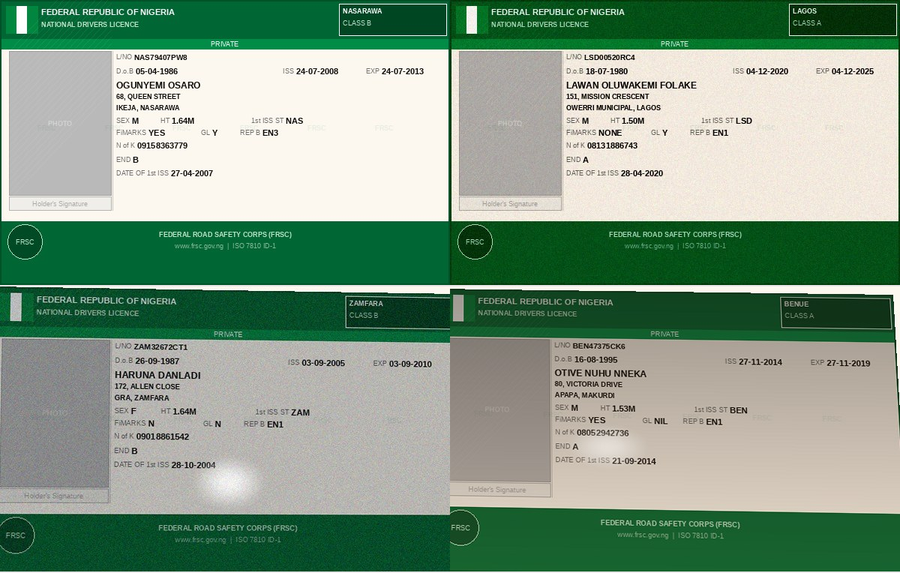

In [14]:
# ─────────────────────────────────────────────────────────
# CELL 13 — Verification & Summary Stats
# ─────────────────────────────────────────────────────────

print('=' * 58)
print('  DATASET SUMMARY')
print('=' * 58)

# Split counts
print('\n  Split distribution:')
for s in ('train', 'val', 'test'):
    count    = manifest['splits'][s]
    img_list = list((DIRS[s]).glob('*.jpg'))
    pct      = count / len(csv_rows) * 100
    print(f'    {s:6s}  {count:5d} images ({pct:.0f}%)  '
          f'[{len(img_list)} files on disk]')

# Field value coverage
print('\n  Field value samples (first 5 rows):')
cols = ['img_path','name','license_no','dob','exp','sex','height']
print(df[cols].head().to_string(index=False))

# State distribution (top 10)
print('\n  Top 10 states by frequency:')
print(df['state'].value_counts().head(10).to_string())

# Expiry distribution
df['exp_date'] = pd.to_datetime(df['exp'], format='%d-%m-%Y', errors='coerce')
expired = (df['exp_date'] < pd.Timestamp.today()).sum()
print(f'\n  Expired licences in dataset: {expired} '
      f'({expired/len(df)*100:.1f}%) — useful for expiry-check testing')

# Disk usage
total_bytes = sum(
    f.stat().st_size
    for split in DIRS.values()
    for f in split.glob('*.jpg')
)
print(f'\n  Total image disk usage: {total_bytes / 1e6:.1f} MB')
print(f'  Average image size:     {total_bytes / max(len(csv_rows),1) / 1e3:.1f} KB')

print(f'\n  Output root: {OUTPUT_ROOT}')
print('=' * 58)

# Display 4 random augmented samples
sample_paths = random.sample(list(DIRS['train'].glob('*.jpg')), min(4, len(csv_rows)))
grid = Image.new('RGB', (W * 2, H * 2 + 4), (230, 230, 230))
for i, p in enumerate(sample_paths):
    im = Image.open(str(p))
    grid.paste(im, ((i % 2) * W, (i // 2) * (H + 2)))
display_w = 900
ratio     = display_w / grid.width
grid.resize((display_w, int(grid.height * ratio)), Image.LANCZOS)

## What's been generated

Your `NigeriaDL_Dataset` folder in Google Drive now contains:

```
NigeriaDL_Dataset/
├── train/images/          ← 4,000 augmented card images (.jpg)
├── val/images/            ← 500 augmented card images
├── test/images/           ← 500 augmented card images
├── field_crops/
│   ├── license_no/        ← 2× upscaled crops of the licence number field
│   ├── name/              ← name field crops
│   ├── dob/               ← DOB field crops
│   ├── exp/               ← expiry date field crops
│   ├── iss/               ← issue date field crops
│   ├── phone/             ← next-of-kin field crops
│   └── first_iss/         ← date of 1st issue crops
├── labels/
│   ├── train_labels.txt   ← PaddleOCR detection format (path + points + text)
│   ├── val_labels.txt
│   └── test_labels.txt
├── clean_reference/       ← unaugmented copies (every 10th train image)
├── ground_truth.csv       ← master CSV with all field values per image
└── dataset_manifest.json  ← metadata, field list, split counts
```

## Next steps

**Option A — Test PaddleOCR out-of-box first (recommended)**  
Run PaddleOCR PP-OCRv4-mobile against 20 images from `test/images/` before fine-tuning.  
If accuracy on `license_no`, `name`, and `dob` is already >90%, you may not need fine-tuning at all.

**Option B — Fine-tune on this dataset**  
The `labels/train_labels.txt` file is in the exact format expected by:  
```bash
python tools/train.py -c configs/rec/PP-OCRv4/en_PP-OCRv4_rec.yml \
  -o Global.data_dir=NigeriaDL_Dataset
```

**Option C — Use field crops for recognition-only fine-tuning**  
The `field_crops/` folder feeds directly into the recognition-only pipeline,  
which is faster to fine-tune than the full detection + recognition pipeline.